In [2]:
!pip install pandas matplotlib

In [6]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
import sqlite3

conn = sqlite3.connect("saas.db")

df.to_sql("customers", conn, if_exists="replace", index=False)

7043

In [8]:
pd.read_sql("""
SELECT COUNT(*) AS total_customers
FROM customers
""", conn)

,total_customers
0,7043


In [9]:
pd.read_sql("""
SELECT Churn, COUNT(*) AS customer_count
FROM customers
GROUP BY Churn
""", conn)

,Churn,customer_count
0,No,5174
1,Yes,1869


In [10]:
pd.read_sql("""
SELECT
ROUND(
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2
) AS churn_rate_percentage
FROM customers
""", conn)

,churn_rate_percentage
0,26.54


In [11]:
pd.read_sql("""
SELECT SUM(MonthlyCharges) AS total_mrr
FROM customers
WHERE Churn='No'
""", conn)

,total_mrr
0,316985.75


In [12]:
revenue_df = pd.read_sql("""
SELECT Contract,
       SUM(MonthlyCharges) AS revenue
FROM customers
GROUP BY Contract
""", conn)

revenue_df

,Contract,revenue
0,Month-to-month,257294.15
1,One year,95816.60
2,Two year,103005.85


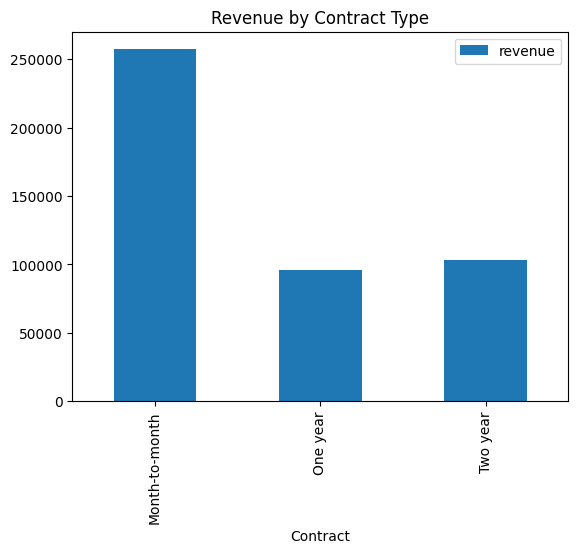

In [13]:
import matplotlib.pyplot as plt

revenue_df.plot(kind="bar", x="Contract", y="revenue")
plt.title("Revenue by Contract Type")
plt.show()

In [15]:
import sqlite3

conn = sqlite3.connect("saas.db")

df.to_sql("customers", conn, if_exists="replace", index=False)

7043

In [21]:
conn.execute("DROP TABLE IF EXISTS customers_info;")
conn.commit()

In [23]:
# Create derived customer table
conn.execute("""
DROP TABLE IF EXISTS customers_info;
""")

conn.execute("""
CREATE TABLE customers_info AS
SELECT customerID, gender, SeniorCitizen, Partner, Dependents
FROM customers;
""")

In [24]:
import pandas as pd

pd.read_sql("SELECT * FROM customers_info LIMIT 5;", conn)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [25]:
pd.read_sql("""
SELECT customerID, tenure, MonthlyCharges
FROM customers
WHERE Contract = 'Month-to-month';
""", conn)

,customerID,tenure,MonthlyCharges
0,7590-VHVEG,1,29.85
1,3668-QPYBK,2,53.85
2,9237-HQITU,2,70.70
3,9305-CDSKC,8,99.65
4,1452-KIOVK,22,89.10
...,...,...,...
3870,9767-FFLEM,38,69.50
3871,0639-TSIQW,67,102.95
3872,8456-QDAVC,19,78.70
3873,4801-JZAZL,11,29.60


In [26]:
pd.read_sql("""
SELECT Contract,
       COUNT(*) AS total_customers,
       AVG(MonthlyCharges) AS avg_monthly_revenue
FROM customers
GROUP BY Contract;
""", conn)

,Contract,total_customers,avg_monthly_revenue
0,Month-to-month,3875,66.398490
1,One year,1473,65.048608
2,Two year,1695,60.770413


In [27]:
pd.read_sql("""
SELECT Contract,
       COUNT(*) AS total_customers,
       AVG(MonthlyCharges) AS avg_revenue
FROM customers
GROUP BY Contract
HAVING AVG(MonthlyCharges) > 60;
""", conn)

,Contract,total_customers,avg_revenue
0,Month-to-month,3875,66.398490
1,One year,1473,65.048608
2,Two year,1695,60.770413


In [28]:
pd.read_sql("""
SELECT c.customerID,
       c.MonthlyCharges,
       ci.gender,
       ci.Partner
FROM customers c
INNER JOIN customers_info ci
ON c.customerID = ci.customerID
LIMIT 10;
""", conn)

,customerID,MonthlyCharges,gender,Partner
0,7590-VHVEG,29.85,Female,Yes
1,5575-GNVDE,56.95,Male,No
2,3668-QPYBK,53.85,Male,No
3,7795-CFOCW,42.30,Male,No
4,9237-HQITU,70.70,Female,No
5,9305-CDSKC,99.65,Female,No
6,1452-KIOVK,89.10,Male,No
7,6713-OKOMC,29.75,Female,No
8,7892-POOKP,104.80,Female,Yes
9,6388-TABGU,56.15,Male,No


In [29]:
pd.read_sql("""
SELECT
    ci.gender,
    COUNT(*) AS total_customers,
    SUM(c.MonthlyCharges) AS MRR,
    AVG(c.MonthlyCharges) AS avg_revenue,
    SUM(CASE WHEN c.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN c.Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
    ) AS churn_rate
FROM customers c
JOIN customers_info ci
ON c.customerID = ci.customerID
GROUP BY ci.gender
HAVING COUNT(*) > 100;
""", conn)

,gender,total_customers,MRR,avg_revenue,churned_customers,churn_rate
0,Female,3488,227432.4,65.204243,939,26.92
1,Male,3555,228684.2,64.327482,930,26.16


In [30]:
pd.read_sql("""
WITH customer_revenue AS (
    SELECT
        customerID,
        MonthlyCharges,
        SUM(MonthlyCharges) OVER () AS total_revenue,
        NTILE(4) OVER (ORDER BY MonthlyCharges DESC) AS revenue_quartile
    FROM customers
)

SELECT
    revenue_quartile,
    COUNT(*) AS customers,
    ROUND(AVG(MonthlyCharges),2) AS avg_revenue
FROM customer_revenue
GROUP BY revenue_quartile
ORDER BY revenue_quartile;
""", conn)

,revenue_quartile,customers,avg_revenue
0,1,1761,100.88
1,2,1761,80.28
2,3,1761,55.65
3,4,1760,22.22


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df_contract = pd.read_sql("""
SELECT
    Contract,
    SUM(MonthlyCharges) AS MRR
FROM customers
GROUP BY Contract
ORDER BY MRR DESC;
""", conn)

df_contract

,Contract,MRR
0,Month-to-month,257294.15
1,Two year,103005.85
2,One year,95816.60


FileNotFoundError: [Errno 2] No such file or directory: 'visuals/mrr_by_contract.png'

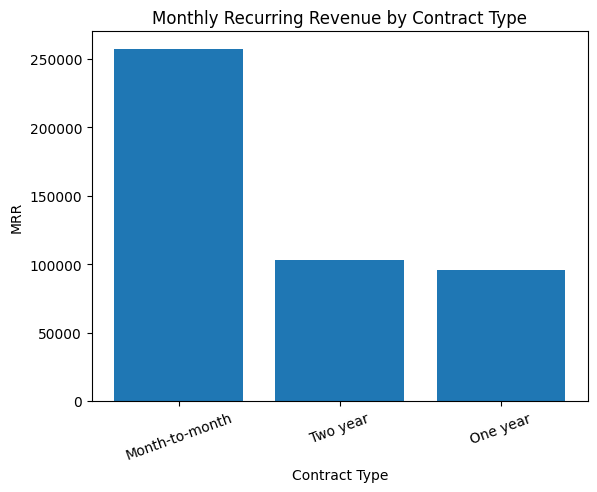

In [33]:
plt.figure()

plt.bar(df_contract['Contract'], df_contract['MRR'])

plt.title("Monthly Recurring Revenue by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("MRR")

plt.xticks(rotation=20)

plt.savefig("visuals/mrr_by_contract.png", bbox_inches='tight')

plt.show()

In [34]:
df_churn = pd.read_sql("""
SELECT
    Contract,
    ROUND(
        100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
    ) AS churn_rate
FROM customers
GROUP BY Contract;
""", conn)

df_churn

,Contract,churn_rate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


FileNotFoundError: [Errno 2] No such file or directory: 'visuals/churn_rate_by_contract.png'

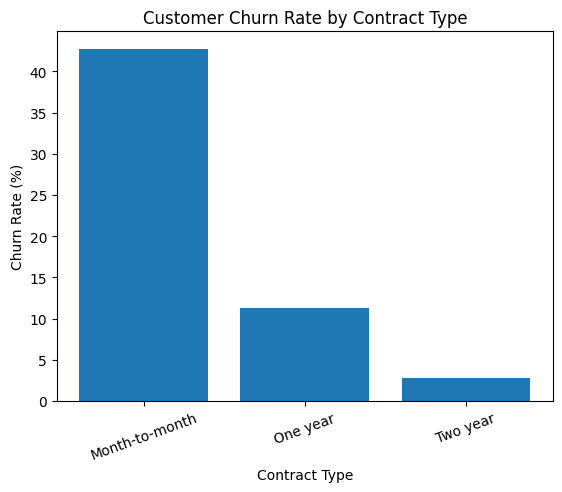

In [35]:
plt.figure()

plt.bar(df_churn['Contract'], df_churn['churn_rate'])

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.savefig("visuals/churn_rate_by_contract.png", bbox_inches='tight')

plt.show()

In [36]:
df_segment = pd.read_sql("""
WITH customer_revenue AS (
    SELECT
        customerID,
        MonthlyCharges,
        NTILE(4) OVER (ORDER BY MonthlyCharges DESC) AS revenue_quartile
    FROM customers
)

SELECT
    revenue_quartile,
    COUNT(*) AS customers,
    ROUND(AVG(MonthlyCharges),2) AS avg_revenue
FROM customer_revenue
GROUP BY revenue_quartile
ORDER BY revenue_quartile;
""", conn)

df_segment

,revenue_quartile,customers,avg_revenue
0,1,1761,100.88
1,2,1761,80.28
2,3,1761,55.65
3,4,1760,22.22


FileNotFoundError: [Errno 2] No such file or directory: 'visuals/revenue_segmentation.png'

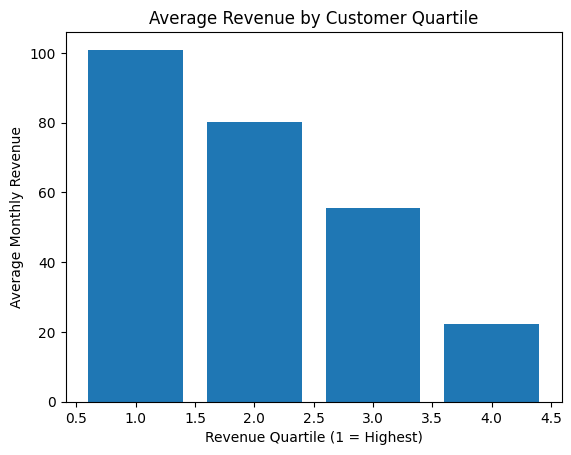

In [37]:
plt.figure()

plt.bar(df_segment['revenue_quartile'], df_segment['avg_revenue'])

plt.title("Average Revenue by Customer Quartile")
plt.xlabel("Revenue Quartile (1 = Highest)")
plt.ylabel("Average Monthly Revenue")

plt.savefig("visuals/revenue_segmentation.png", bbox_inches='tight')

plt.show()